## Imports

In [23]:
import rasterio
from rasterio.plot import show
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import pyodbc
import pandas as pd
import xarray as xr



Driver: EHdr
Width, Height: 43200 21600
Count (bands): 1
Dtype: ('uint16',)
CRS: OGC:CRS84
Transform: | 0.01, 0.00,-180.00|
| 0.00,-0.01, 90.00|
| 0.00, 0.00, 1.00|
Bounds: BoundingBox(left=-179.99999999999966, bottom=-89.99999999999996, right=180.00000000000017, top=89.99999999999996)
Nodata: 65535.0
Preview shape: (432, 864)
Preview min/max: 2.0 65535.0


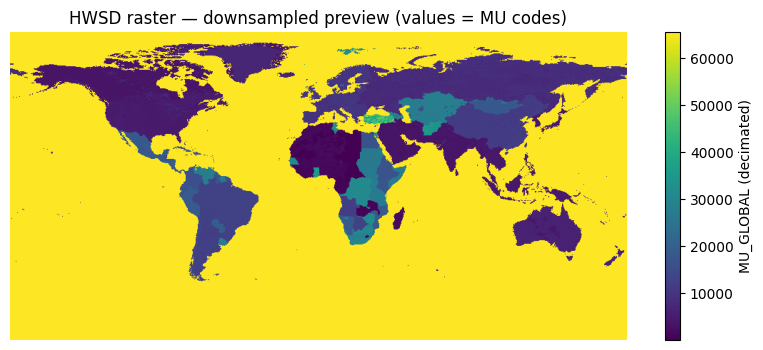

In [24]:
raster_dir = Path(r"D:\DataMining\Fire-Detection-Data-Mining-Project\Datasets\SoilDataset\HWSD2_RASTER")
bil = raster_dir / "HWSD2.bil"
hdr = raster_dir / "HWSD2.hdr"
prj = raster_dir / "HWSD2.prj"

# open with rasterio (it reads hdr/prj automatically when same basename)
with rasterio.open(str(bil)) as src:
    print("Driver:", src.driver)
    print("Width, Height:", src.width, src.height)
    print("Count (bands):", src.count)
    print("Dtype:", src.dtypes)
    print("CRS:", src.crs)
    print("Transform:", src.transform)
    print("Bounds:", src.bounds)
    print("Nodata:", src.nodata)

    # Fast, lower-resolution preview: read a decimated overview to avoid memory blowup
    # choose out_shape ~ 1024x512 or similar (keeps aspect)
    out_shape = (int(src.height / 50), int(src.width / 50))  # tune divisor for speed
    arr = src.read(1, out_shape=out_shape)  # downsampled array
    print("Preview shape:", arr.shape)
    print("Preview min/max:", float(np.nanmin(arr)), float(np.nanmax(arr)))

# Plot preview
plt.figure(figsize=(10,4))
plt.imshow(arr, origin="upper")
plt.title("HWSD raster — downsampled preview (values = MU codes)")
plt.colorbar(label="MU_GLOBAL (decimated)")
plt.axis("off")
plt.show()


In [25]:
with rasterio.open(str(bil)) as src:
    # read a coarse decimation to get a representative sample
    ds_factor = 100  # larger → smaller sample; tune as needed
    sample = src.read(1, out_shape=(src.count, src.height//ds_factor, src.width//ds_factor))
    sample = sample.squeeze()
    # mask out nodata:
    nod = src.nodata
    if nod is not None:
        sample_flat = sample[sample != nod].ravel()
    else:
        sample_flat = sample.ravel()

    # get frequency of codes in sample
    uniq, counts = np.unique(sample_flat, return_counts=True)
    freq = list(zip(uniq, counts))
    freq_sorted = sorted(freq, key=lambda x: x[1], reverse=True)
    print("Top 20 MU codes in sampled raster (code, count_in_sample):")
    print(freq_sorted[:20])


Top 20 MU codes in sampled raster (code, count_in_sample):
[(np.uint16(6998), np.int64(945)), (np.uint16(3482), np.int64(331)), (np.uint16(3479), np.int64(269)), (np.uint16(36), np.int64(179)), (np.uint16(6997), np.int64(160)), (np.uint16(4952), np.int64(120)), (np.uint16(6043), np.int64(114)), (np.uint16(3478), np.int64(98)), (np.uint16(3508), np.int64(93)), (np.uint16(3366), np.int64(90)), (np.uint16(7111), np.int64(88)), (np.uint16(4284), np.int64(84)), (np.uint16(6189), np.int64(83)), (np.uint16(8495), np.int64(81)), (np.uint16(3390), np.int64(75)), (np.uint16(4035), np.int64(74)), (np.uint16(6090), np.int64(68)), (np.uint16(8044), np.int64(67)), (np.uint16(7515), np.int64(62)), (np.uint16(3343), np.int64(61))]


In [26]:
coords = [
    (2.0, 36.7),   # northern Algeria near Algiers
    (7.9, 36.8),   # near Tunis
    (1.0, 30.0),   # more south
]

with rasterio.open(str(bil)) as src:
    for lon, lat in coords:
        # transform lon/lat to row/col
        row, col = src.index(lon, lat)   # src.index expects (x, y) in src CRS
        try:
            val = src.read(1)[row, col]
        except IndexError:
            val = src.read(1, window=((row, row+1),(col, col+1)))[0,0]
        print(f"Point ({lon},{lat}) -> MU code: {val}")


Point (2.0,36.7) -> MU code: 65535
Point (7.9,36.8) -> MU code: 1725
Point (1.0,30.0) -> MU code: 36


In [27]:
print("--- HDR file ---")
print(open(str(hdr)).read()[:4000])   # first chunk

print("--- PRJ file ---")
print(open(str(prj)).read())


--- HDR file ---
BYTEORDER      I
LAYOUT         BIL
NROWS          21600
NCOLS          43200
NBANDS         1
NBITS          16
BANDROWBYTES   86400
TOTALROWBYTES  86400
PIXELTYPE      UNSIGNEDINT
ULXMAP         -179.995833333333
ULYMAP         89.9958333333333
XDIM           0.00833333333333333
YDIM           0.00833333333333333
NODATA         65535

--- PRJ file ---
GEOGCS["GCS_WGS_1984",DATUM["D_WGS_1984",SPHEROID["WGS_1984",6378137.0,298.257223563]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]]



In [28]:
stx = raster_dir / "HWSD2.stx"
try:
    print(open(str(stx), "r", encoding="utf-8", errors="replace").read()[:2000])
except Exception as e:
    print("Cannot open as text (binary). Use OS tools like `strings` or inspect in a hex editor. Error:", e)


1 2.0000000000 49830.0000000000 9738.2895044269 7938.7485118103



In [29]:
mdb_path = r"D:\DataMining\Fire-Detection-Data-Mining-Project\Datasets\SoilDataset\HWSD2_DB\HWSD2.mdb"

conn_str = (
    r"DRIVER={Microsoft Access Driver (*.mdb, *.accdb)};"
    rf"DBQ={mdb_path};"
)
conn = pyodbc.connect(conn_str, autocommit=True)
cursor = conn.cursor()

# list tables
tables = [row.table_name for row in cursor.tables(tableType='TABLE')]
print("Tables in MDB:", tables)

# Microsoft Access SQL uses TOP instead of LIMIT — request the first 5 rows
for t in tables:
    print("--", t)
    print(pd.read_sql(f"SELECT TOP 5 * FROM [{t}]", conn))
    break

# close
cursor.close()
conn.close()

Tables in MDB: ['D_ADD_PROP', 'D_AWC', 'D_COVERAGE', 'D_DRAINAGE', 'D_FAO90', 'D_IL', 'D_KOPPEN', 'D_PHASE', 'D_ROOT_DEPTH', 'D_ROOTS', 'D_SWR', 'D_TEXTURE', 'D_TEXTURE_SOTER', 'D_TEXTURE_USDA', 'D_WRB_PHASES', 'D_WRB2', 'D_WRB2code', 'D_WRB4', 'HWSD2_LAYERS', 'HWSD2_LAYERS_METADATA', 'HWSD2_SMU', 'HWSD2_SMU_METADATA', 'WRB_Class', 'WRB_Layer', 'WRB_Library']
-- D_ADD_PROP
   CODE   VALUE
0     0    None
1     2   Gelic
2     3  Vertic


C:\Users\E15\AppData\Local\Temp\ipykernel_4348\1994260136.py:17: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  print(pd.read_sql(f"SELECT TOP 5 * FROM [{t}]", conn))


In [30]:
MDB = r"D:\DataMining\Fire-Detection-Data-Mining-Project\Datasets\SoilDataset\HWSD2_DB\HWSD2.mdb"

conn = pyodbc.connect(
    rf"DRIVER={{Microsoft Access Driver (*.mdb, *.accdb)}};DBQ={MDB};",
    autocommit=True
)
cur = conn.cursor()

# 1) list all user tables
tables = [row.table_name for row in cur.tables(tableType='TABLE')]
print("TABLES:", tables)

# 2) print columns for each table
schema = {}
for t in tables:
    cols = [r.column_name for r in cur.columns(table=t)]
    schema[t] = cols
    print(f"\n-- {t} --")
    print(", ".join(cols))

# 3) (optional) peek first 5 rows of each table safely
for t in tables:
    try:
        df = pd.read_sql_query(f"SELECT TOP 5 * FROM [{t}]", conn)
        print(f"\nSample rows from {t}:")
        print(df.head())
    except Exception as e:
        print(f"\nCould not preview {t}: {e}")

cur.close()
conn.close()

TABLES: ['D_ADD_PROP', 'D_AWC', 'D_COVERAGE', 'D_DRAINAGE', 'D_FAO90', 'D_IL', 'D_KOPPEN', 'D_PHASE', 'D_ROOT_DEPTH', 'D_ROOTS', 'D_SWR', 'D_TEXTURE', 'D_TEXTURE_SOTER', 'D_TEXTURE_USDA', 'D_WRB_PHASES', 'D_WRB2', 'D_WRB2code', 'D_WRB4', 'HWSD2_LAYERS', 'HWSD2_LAYERS_METADATA', 'HWSD2_SMU', 'HWSD2_SMU_METADATA', 'WRB_Class', 'WRB_Layer', 'WRB_Library']

-- D_ADD_PROP --
CODE, VALUE

-- D_AWC --
CODE, VALUE

-- D_COVERAGE --
CODE, VALUE

-- D_DRAINAGE --
SYMBOL, CODE, VALUE

-- D_FAO90 --
SYMBOL, CODE, VALUE

-- D_IL --
CODE, VALUE

-- D_KOPPEN --
CODE, VALUE

-- D_PHASE --
CODE, VALUE

-- D_ROOT_DEPTH --
CODE, VALUE

-- D_ROOTS --
CODE, VALUE

-- D_SWR --
CODE, VALUE

-- D_TEXTURE --
CODE, VALUE

-- D_TEXTURE_SOTER --
CODE, VALUE

-- D_TEXTURE_USDA --
CODE, VALUE

-- D_WRB_PHASES --
ID, CODE, VALUE

-- D_WRB2 --
CODE, Value

-- D_WRB2code --
CODE, Value

-- D_WRB4 --
ID, VALUE, CODE

-- HWSD2_LAYERS --
ID, HWSD2_SMU_ID, NSC_MU_SOURCE1, NSC_MU_SOURCE2, WISE30s_SMU_ID, HWSD1_SMU_ID, COVE

C:\Users\E15\AppData\Local\Temp\ipykernel_4348\3552248666.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(f"SELECT TOP 5 * FROM [{t}]", conn)
C:\Users\E15\AppData\Local\Temp\ipykernel_4348\3552248666.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(f"SELECT TOP 5 * FROM [{t}]", conn)
C:\Users\E15\AppData\Local\Temp\ipykernel_4348\3552248666.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(f"SELECT TOP 5 * FROM [{t}]", conn)
C:\Users\E15\AppDat

In [31]:
import geopandas as gpd
AOI = r"D:\DataMining\Fire-Detection-Data-Mining-Project\ExtractedDatasets\GeoBoundaries\AOI_DZA_TUN\aoi_dza_tun.gpkg"
aoi = gpd.read_file(AOI).to_crs("EPSG:4326")
aoi

,name,geometry
0,DZA_TUN,"MULTIPOLYGON (((-8.65212 28.71899, -8.65006 28..."


CRS: OGC:CRS84
Resolution: (0.00833333333333333, 0.00833333333333333)
Shape: 43200 x 21600
Bounds: BoundingBox(left=-179.99999999999966, bottom=-89.99999999999996, right=180.00000000000017, top=89.99999999999996)


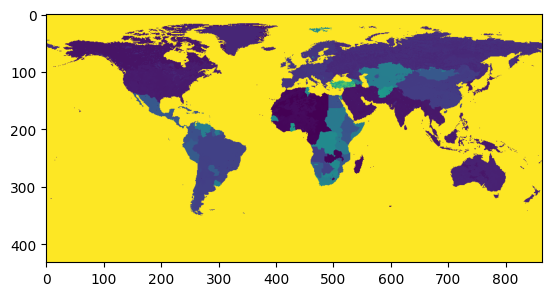

In [32]:
import rasterio
from rasterio.plot import show

raster_path = r"D:\DataMining\Fire-Detection-Data-Mining-Project\Datasets\SoilDataset\HWSD2_RASTER\HWSD2.bil"

with rasterio.open(raster_path) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Shape:", src.width, "x", src.height)
    print("Bounds:", src.bounds)
    show(src.read(1)[::50, ::50])  # quick low-res preview


Clipped shape: (2229, 2479)
Clipped bounds: (-8.666666666666405, 18.966666666666665, 11.991666666666934, 37.54166666666666)


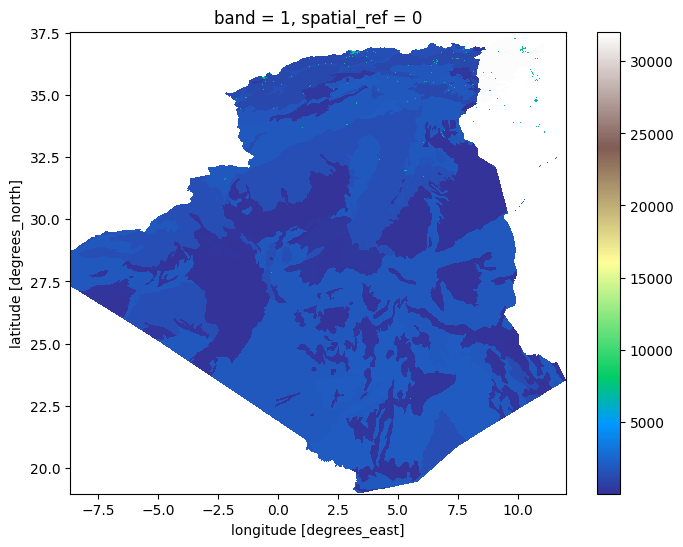

In [35]:
import rioxarray as rxr

# Load with rioxarray for clipping convenience
da = rxr.open_rasterio(raster_path, masked=True).squeeze()
da = da.rio.write_crs("EPSG:4326", inplace=False)

# Clip to AOI
da_clip = da.rio.clip(aoi.geometry, aoi.crs)
print("Clipped shape:", da_clip.shape)
print("Clipped bounds:", da_clip.rio.bounds())

# Preview
da_clip.plot(cmap="terrain", figsize=(8,6))
